In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import (train_test_split, StratifiedKFold, cross_val_score)
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import (
    precision_recall_curve, classification_report, accuracy_score,
    roc_auc_score, confusion_matrix, average_precision_score,
    brier_score_loss, RocCurveDisplay, PrecisionRecallDisplay, f1_score
)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.ensemble import BalancedRandomForestClassifier

# ---------------------------------------------------------
# 1. Data Loading and Exploration
# ---------------------------------------------------------
path = 'data/heart_2020_cleaned.csv'
df = pd.read_csv(path)
print(f"-> Data loaded. Rows/Columns: {df.shape}")
print(f"-> Target distribution:\n{df['HeartDisease'].value_counts(normalize=True).round(3)}")


-> Data loaded. Rows/Columns: (319795, 18)
-> Target distribution:
HeartDisease
No     0.914
Yes    0.086
Name: proportion, dtype: float64


In [16]:
# ---------------------------------------------------------
# 2. Data Cleaning
# ---------------------------------------------------------

print(f"-> Number of Missing Values: {df.isnull().sum().sum()}")

initial_count = len(df)
df = df.drop_duplicates()
print(f"-> {initial_count - len(df)} duplicate rows removed.")


-> Number of Missing Values: 0
-> 18078 duplicate rows removed.


In [17]:
# ---------------------------------------------------------
# 3. Feature Engineering
# ---------------------------------------------------------

df['BMI_Category'] = pd.cut(df['BMI'], bins=[0, 18.5, 25, 30, 100],
                             labels=['Underweight', 'Normal', 'Overweight', 'Obese'])

health_map = {'Poor': 0, 'Fair': 1, 'Good': 2, 'Very good': 3, 'Excellent': 4}
df['GenHealth_Score'] = df['GenHealth'].map(health_map)

# Interaction & risk composite features
df['PhysicalHealth_MentalHealth'] = df['PhysicalHealth'] * df['MentalHealth']
df['SleepTime_BMI']               = df['SleepTime'] * df['BMI']
df['Poor_Health_Days']            = df['PhysicalHealth'] + df['MentalHealth']
# Low sleep (<6h) as binary flag
df['Short_Sleep']                 = (df['SleepTime'] < 6).astype(int)

le = LabelEncoder()
binary_cols = ['HeartDisease', 'Smoking', 'AlcoholDrinking', 'Stroke', 'DiffWalking',
               'Sex', 'PhysicalActivity', 'Asthma', 'KidneyDisease', 'SkinCancer']
for col in binary_cols:
    df[col] = le.fit_transform(df[col])

df = pd.get_dummies(df, columns=['AgeCategory', 'Race', 'Diabetic', 'BMI_Category'], drop_first=True)
print(f"-> Feature engineering done. Shape: {df.shape}")


-> Feature engineering done. Shape: (301717, 43)


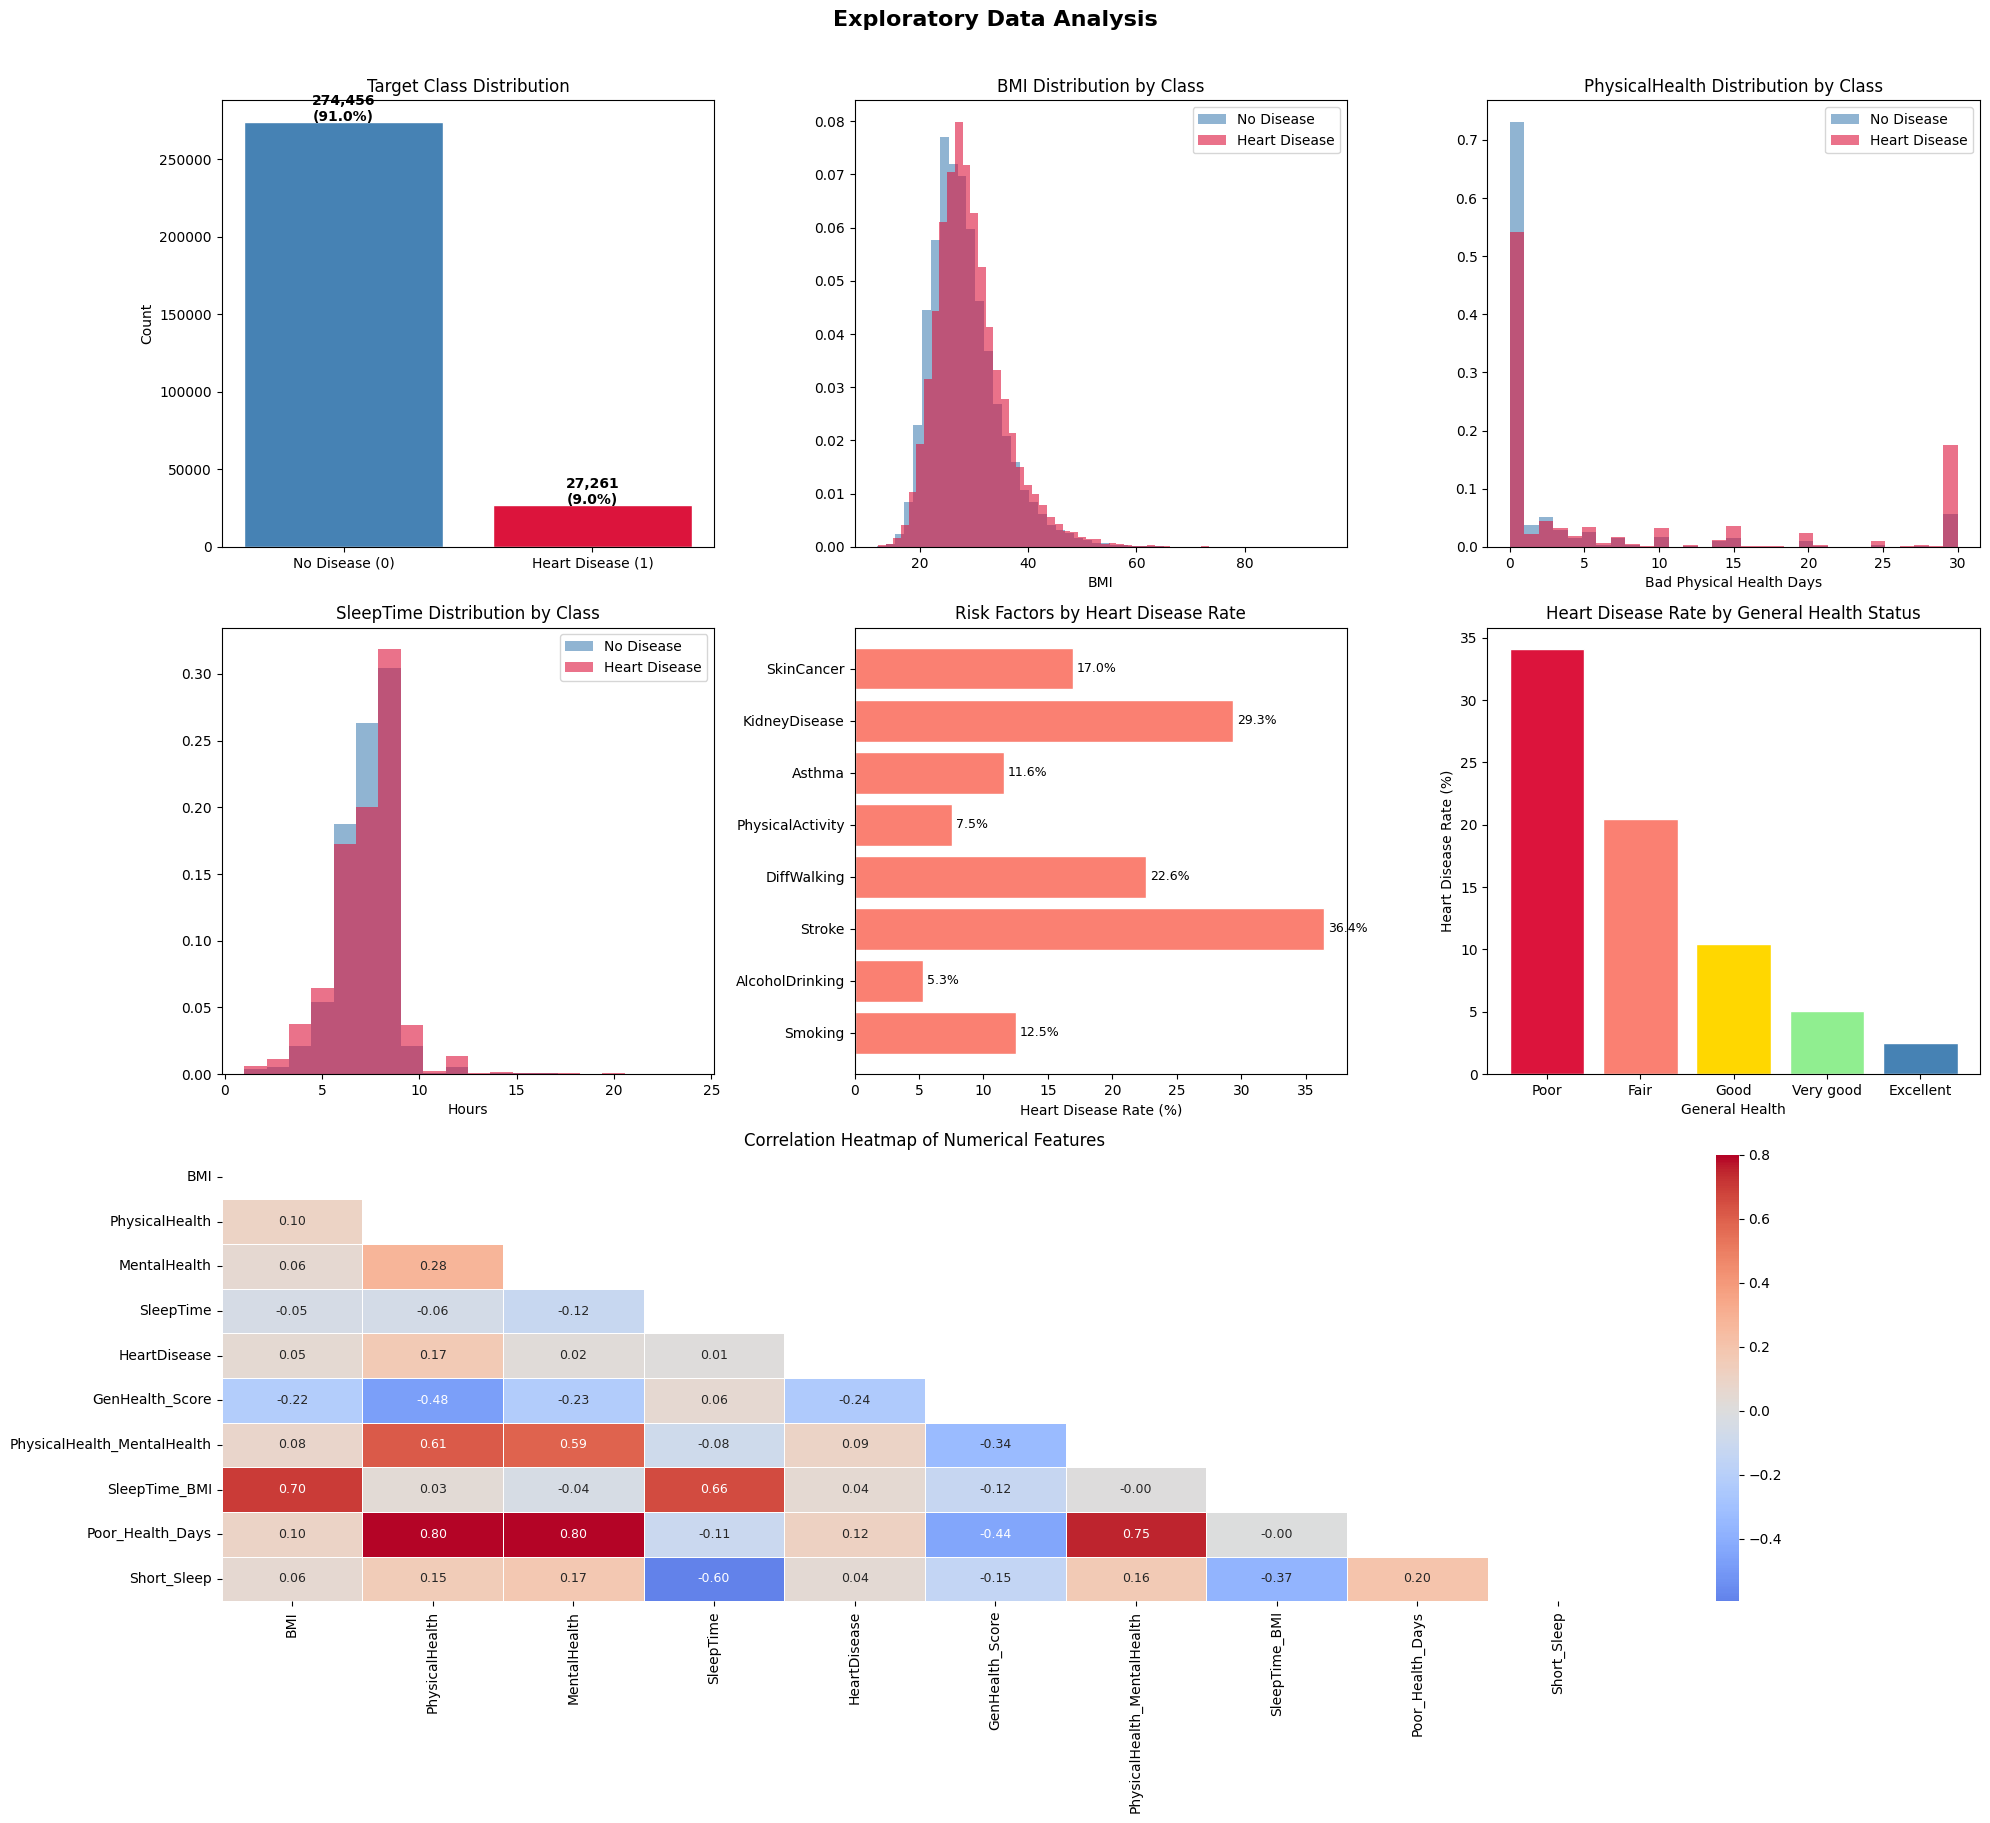

In [18]:
# ---------------------------------------------------------
# EDA
# ---------------------------------------------------------

fig = plt.figure(figsize=(20, 18))
fig.suptitle("Exploratory Data Analysis", fontsize=16, fontweight='bold', y=1.01)

# 1. Target class distribution
ax1 = fig.add_subplot(3, 3, 1)
counts = df['HeartDisease'].value_counts()
ax1.bar(['No Disease (0)', 'Heart Disease (1)'], counts.values,
        color=['steelblue', 'crimson'], edgecolor='white')
for i, v in enumerate(counts.values):
    ax1.text(i, v + 200, f"{v:,}\n({v/len(df)*100:.1f}%)",
             ha='center', fontsize=10, fontweight='bold')
ax1.set_title("Target Class Distribution")
ax1.set_ylabel("Count")

# 2. BMI distribution by class
ax2 = fig.add_subplot(3, 3, 2)
for label, color, name in [(0, 'steelblue', 'No Disease'), (1, 'crimson', 'Heart Disease')]:
    ax2.hist(df[df['HeartDisease'] == label]['BMI'], bins=50,
             alpha=0.6, color=color, label=name, density=True)
ax2.set_title("BMI Distribution by Class")
ax2.set_xlabel("BMI"); ax2.legend()

# 3. PhysicalHealth distribution by class
ax3 = fig.add_subplot(3, 3, 3)
for label, color, name in [(0, 'steelblue', 'No Disease'), (1, 'crimson', 'Heart Disease')]:
    ax3.hist(df[df['HeartDisease'] == label]['PhysicalHealth'], bins=31,
             alpha=0.6, color=color, label=name, density=True)
ax3.set_title("PhysicalHealth Distribution by Class")
ax3.set_xlabel("Bad Physical Health Days"); ax3.legend()

# 4. SleepTime distribution by class
ax4 = fig.add_subplot(3, 3, 4)
for label, color, name in [(0, 'steelblue', 'No Disease'), (1, 'crimson', 'Heart Disease')]:
    ax4.hist(df[df['HeartDisease'] == label]['SleepTime'], bins=20,
             alpha=0.6, color=color, label=name, density=True)
ax4.set_title("SleepTime Distribution by Class")
ax4.set_xlabel("Hours"); ax4.legend()

# 5. Categorical risk factors — heart disease rate
ax5 = fig.add_subplot(3, 3, 5)
cat_cols = ['Smoking', 'AlcoholDrinking', 'Stroke', 'DiffWalking',
            'PhysicalActivity', 'Asthma', 'KidneyDisease', 'SkinCancer']
rates = {c: df[df[c] == 1]['HeartDisease'].mean() * 100 for c in cat_cols}
bars = ax5.barh(list(rates.keys()), list(rates.values()),
                color='salmon', edgecolor='white')
ax5.set_xlabel("Heart Disease Rate (%)"); ax5.set_title("Risk Factors by Heart Disease Rate")
for bar, val in zip(bars, rates.values()):
    ax5.text(val + 0.3, bar.get_y() + bar.get_height()/2,
             f"{val:.1f}%", va='center', fontsize=9)

# 6. GenHealth distribution by class — heart disease rate
ax6 = fig.add_subplot(3, 3, 6)
gh_order = ['Poor', 'Fair', 'Good', 'Very good', 'Excellent']
gh_map   = {'Poor': 0, 'Fair': 1, 'Good': 2, 'Very good': 3, 'Excellent': 4}
# Use original GenHealth before encoding
df_raw_gh = pd.read_csv('data/heart_2020_cleaned.csv').drop_duplicates()
gh_rates  = {g: df_raw_gh[df_raw_gh['GenHealth'] == g]['HeartDisease']
             .apply(lambda x: 1 if x == 'Yes' else 0).mean() * 100
             for g in gh_order}
ax6.bar(gh_order, [gh_rates[g] for g in gh_order],
        color=['crimson', 'salmon', 'gold', 'lightgreen', 'steelblue'],
        edgecolor='white')
ax6.set_title("Heart Disease Rate by General Health Status")
ax6.set_ylabel("Heart Disease Rate (%)"); ax6.set_xlabel("General Health")

# 7. Correlation heatmap (numerical features)
ax7 = fig.add_subplot(3, 3, (7, 9))
# Correlation for only numerical columns (EDA is done before encoding)
num_cols_candidates = ['BMI', 'PhysicalHealth', 'MentalHealth', 'SleepTime',
                       'HeartDisease', 'GenHealth_Score',
                       'PhysicalHealth_MentalHealth', 'SleepTime_BMI',
                       'Poor_Health_Days', 'Short_Sleep']
num_cols = [c for c in num_cols_candidates
            if c in df.columns and pd.api.types.is_numeric_dtype(df[c])]
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax7, annot_kws={"size": 9})
ax7.set_title("Correlation Heatmap of Numerical Features")

plt.tight_layout()
plt.show()


In [19]:
# ---------------------------------------------------------
# 4. Train/Test Split  (FIXED: split BEFORE any fitting)
# ---------------------------------------------------------

X = df.drop(['HeartDisease', 'GenHealth'], axis=1)
y = df['HeartDisease']

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"-> Train size: {X_train_raw.shape}, Test size: {X_test_raw.shape}")
print(f"-> Train positive rate: {y_train.mean():.3f}, Test positive rate: {y_test.mean():.3f}")


-> Train size: (241373, 41), Test size: (60344, 41)
-> Train positive rate: 0.090, Test positive rate: 0.090


In [20]:
# ---------------------------------------------------------
# 5. Model Pipelines  (recall-focused)
# ---------------------------------------------------------

neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
spw = neg / pos
print(f"-> Class imbalance ratio (scale_pos_weight): {spw:.2f}")

# ---------- XGBoost ----------
xgb_pipe = ImbPipeline([
    ('smote',  SMOTE(random_state=42, k_neighbors=5)),
    ('scaler', StandardScaler()),
    ('select', SelectKBest(score_func=f_classif, k=25)),
    ('model',  XGBClassifier(
        n_estimators=400,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_weight=3,
        scale_pos_weight=spw,      # extra push toward minority class
        eval_metric='aucpr',       # optimise PR-AUC (better for imbalance than logloss)
        use_label_encoder=False,
        random_state=42,
        n_jobs=-1
    ))
])

# ---------- LightGBM ----------
lgbm_pipe = ImbPipeline([
    ('smote',  SMOTE(random_state=42, k_neighbors=5)),
    ('scaler', StandardScaler()),
    ('select', SelectKBest(score_func=f_classif, k=25)),
    ('model',  LGBMClassifier(
        n_estimators=400,
        max_depth=6,
        learning_rate=0.05,
        num_leaves=63,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_samples=10,
        class_weight='balanced',
        is_unbalance=True,
        random_state=42,
        n_jobs=-1,
        verbose=-1
    ))
])

# ---------- BalancedRandomForest ----------
# Trains on balanced bootstrap samples natively — strong baseline for recall
brf_pipe = ImbPipeline([
    ('scaler', StandardScaler()),
    ('select', SelectKBest(score_func=f_classif, k=25)),
    ('model',  BalancedRandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        class_weight='balanced_subsample',
        sampling_strategy='all',
        replacement=True,
        random_state=42,
        n_jobs=-1
    ))
])

# ---------- Cross-validation ----------
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, pipe in [('XGBoost', xgb_pipe), ('LightGBM', lgbm_pipe), ('BalancedRF', brf_pipe)]:
    scores = cross_val_score(pipe, X_train_raw, y_train, cv=skf, scoring='average_precision', n_jobs=-1)
    print(f"-> {name:<12} PR-AUC CV: {scores.mean():.4f} ± {scores.std():.4f}")



-> Class imbalance ratio (scale_pos_weight): 10.07
-> XGBoost      PR-AUC CV: 0.2495 ± 0.0041
-> LightGBM     PR-AUC CV: 0.2479 ± 0.0032
-> BalancedRF   PR-AUC CV: 0.3153 ± 0.0052


In [21]:
# ---------------------------------------------------------
# 5b. Hiperparametre Tuning (LightGBM) — optimize PR-AUC
# ---------------------------------------------------------

from sklearn.model_selection import RandomizedSearchCV

lgbm_tune_pipe = ImbPipeline([
    ('smote',  SMOTE(random_state=42, k_neighbors=5)),
    ('scaler', StandardScaler()),
    ('select', SelectKBest(score_func=f_classif, k=25)),
    ('model',  LGBMClassifier(
        class_weight='balanced', is_unbalance=True,
        random_state=42, n_jobs=-1, verbose=-1
    ))
])

param_dist = {
    'model__n_estimators':    [200, 300, 400, 500],
    'model__max_depth':       [4, 5, 6, 7, -1],
    'model__learning_rate':   [0.01, 0.03, 0.05, 0.1],
    'model__num_leaves':      [31, 63, 127],
    'model__subsample':       [0.7, 0.8, 0.9],
    'model__colsample_bytree':[0.7, 0.8, 0.9],
    'model__min_child_samples':[5, 10, 20],
    'model__reg_alpha':       [0, 0.1, 0.5],
    'model__reg_lambda':      [0, 0.1, 1.0],
}

skf_tune = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

rscv = RandomizedSearchCV(
    lgbm_tune_pipe,
    param_distributions=param_dist,
    n_iter=30,                  # 30 rastgele kombinasyon dene
    scoring='average_precision', # PR-AUC ile optimize et
    cv=skf_tune,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

print("-> RandomizedSearchCV started...")
rscv.fit(X_train_raw, y_train)

print(f"\n-> The Best PR-AUC (CV): {rscv.best_score_:.4f}")
print(f"-> The Best parameters:")
for k, v in rscv.best_params_.items():
    print(f"   {k:<35} = {v}")

lgbm_tuned = rscv.best_estimator_
proba_lgbm_tuned = lgbm_tuned.predict_proba(X_test_raw)[:, 1]



-> RandomizedSearchCV started...
Fitting 3 folds for each of 30 candidates, totalling 90 fits

-> The Best PR-AUC (CV): 0.2665
-> The Best parameters:
   model__subsample                    = 0.9
   model__reg_lambda                   = 0.1
   model__reg_alpha                    = 0.5
   model__num_leaves                   = 63
   model__n_estimators                 = 400
   model__min_child_samples            = 20
   model__max_depth                    = 4
   model__learning_rate                = 0.01
   model__colsample_bytree             = 0.7


In [ ]:
# ---------------------------------------------------------
# 6. Final Fit on Full Training Set
# ---------------------------------------------------------

print("-> Fitting XGBoost ...")
xgb_pipe.fit(X_train_raw, y_train)

print("-> Fitting LightGBM (tuned) ...")
# Use tuned pipeline if HPO was run, otherwise fall back to default
if 'lgbm_tuned' in dir():
    
    lgbm_pipe = lgbm_tuned
lgbm_pipe.fit(X_train_raw, y_train)

print("-> Fitting BalancedRandomForest ...")
brf_pipe.fit(X_train_raw, y_train)

print("-> All models fitted.")

# Collect probabilities
proba_xgb  = xgb_pipe.predict_proba(X_test_raw)[:, 1]
proba_lgbm = lgbm_pipe.predict_proba(X_test_raw)[:, 1]
proba_brf  = brf_pipe.predict_proba(X_test_raw)[:, 1]

# Soft ensemble: weighted average (give more weight to LGBM & BRF which focus on recall)
proba_ens = 0.30 * proba_xgb + 0.35 * proba_lgbm + 0.35 * proba_brf

print("-> Probabilities computed for all models.")

# HPO comparison
if 'lgbm_tuned' in dir():
    from sklearn.metrics import average_precision_score as aps
    pipe_default = ImbPipeline([
        ('smote',  SMOTE(random_state=42, k_neighbors=5)),
        ('scaler', StandardScaler()),
        ('select', SelectKBest(score_func=f_classif, k=25)),
        ('model',  LGBMClassifier(n_estimators=400, max_depth=6, learning_rate=0.05,
                                  num_leaves=63, subsample=0.8, colsample_bytree=0.8,
                                  min_child_samples=10, class_weight='balanced',
                                  is_unbalance=True, random_state=42, n_jobs=-1, verbose=-1))
    ])
    pipe_default.fit(X_train_raw, y_train)
    prauc_default = aps(y_test, pipe_default.predict_proba(X_test_raw)[:, 1])
    prauc_tuned   = aps(y_test, proba_lgbm)
    print(f"\n-> LightGBM (default) PR-AUC : {prauc_default:.4f}")
    print(f"-> LightGBM (tuned)      PR-AUC : {prauc_tuned:.4f}")
    print(f"-> Improvement             : {(prauc_tuned - prauc_default)*100:+.2f} points")


-> Fitting XGBoost ...
-> Fitting LightGBM (tuned) ...
-> Fitting BalancedRandomForest ...
-> All models fitted.
-> Probabilities computed for all models.

-> LightGBM (default) PR-AUC : 0.2477
-> LightGBM (tuned)      PR-AUC : 0.2627
-> Improvement             : +1.50 points


In [23]:
# ---------------------------------------------------------
# 7. Threshold Optimisation & Metrics
# ---------------------------------------------------------

def evaluate(name, y_test, y_proba):
    precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)

    # Threshold 1: max F1
    f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-10)
    opt_idx   = np.argmax(f1_scores)
    thr_f1    = thresholds[opt_idx]

    # Threshold 2: recall >= 0.70 with highest precision
    recall_mask = recalls[:-1] >= 0.70
    if recall_mask.any():
        thr_r70 = thresholds[np.where(recall_mask)[0][-1]]  # highest threshold still hitting 0.70
    else:
        thr_r70 = thr_f1

    print(f"\n{'='*55}")
    print(f"  {name}")
    print(f"{'='*55}")
    for label, thr in [('Max-F1 threshold', thr_f1), ('Recall≥0.70 threshold', thr_r70)]:
        y_pred = (y_proba >= thr).astype(int)
        rec  = (y_pred[y_test == 1] == 1).mean()
        prec = (y_test[y_pred == 1] == 1).mean() if y_pred.sum() > 0 else 0
        print(f"  [{label}  thr={thr:.3f}]  Recall={rec:.3f}  Precision={prec:.3f}  "
              f"F1={f1_score(y_test, y_pred):.3f}")

    print(f"  ROC-AUC : {roc_auc_score(y_test, y_proba):.4f}")
    print(f"  PR-AUC  : {average_precision_score(y_test, y_proba):.4f}")
    print(f"  Brier   : {brier_score_loss(y_test, y_proba):.4f}")
    print(f"\n  Full report (Max-F1 threshold):")
    print(classification_report(y_test, (y_proba >= thr_f1).astype(int),
                                 target_names=['No Disease', 'Heart Disease']))
    return thr_f1, thr_r70

thr_xgb_f1,  thr_xgb_r70  = evaluate("XGBoost",            y_test, proba_xgb)
thr_lgbm_f1, thr_lgbm_r70 = evaluate("LightGBM",           y_test, proba_lgbm)
thr_brf_f1,  thr_brf_r70  = evaluate("BalancedRandomForest", y_test, proba_brf)
thr_ens_f1,  thr_ens_r70  = evaluate("Ensemble",            y_test, proba_ens)



  XGBoost
  [Max-F1 threshold  thr=0.872]  Recall=0.519  Precision=0.236  F1=0.324
  [Recall≥0.70 threshold  thr=0.765]  Recall=0.700  Precision=0.203  F1=0.315
  ROC-AUC : 0.7858
  PR-AUC  : 0.2499
  Brier   : 0.3052

  Full report (Max-F1 threshold):
               precision    recall  f1-score   support

   No Disease       0.95      0.83      0.89     54892
Heart Disease       0.24      0.52      0.32      5452

     accuracy                           0.80     60344
    macro avg       0.59      0.68      0.61     60344
 weighted avg       0.88      0.80      0.84     60344


  LightGBM
  [Max-F1 threshold  thr=0.505]  Recall=0.534  Precision=0.252  F1=0.342
  [Recall≥0.70 threshold  thr=0.394]  Recall=0.700  Precision=0.211  F1=0.324
  ROC-AUC : 0.7918
  PR-AUC  : 0.2627
  Brier   : 0.1318

  Full report (Max-F1 threshold):
               precision    recall  f1-score   support

   No Disease       0.95      0.84      0.89     54892
Heart Disease       0.25      0.53      0.34   

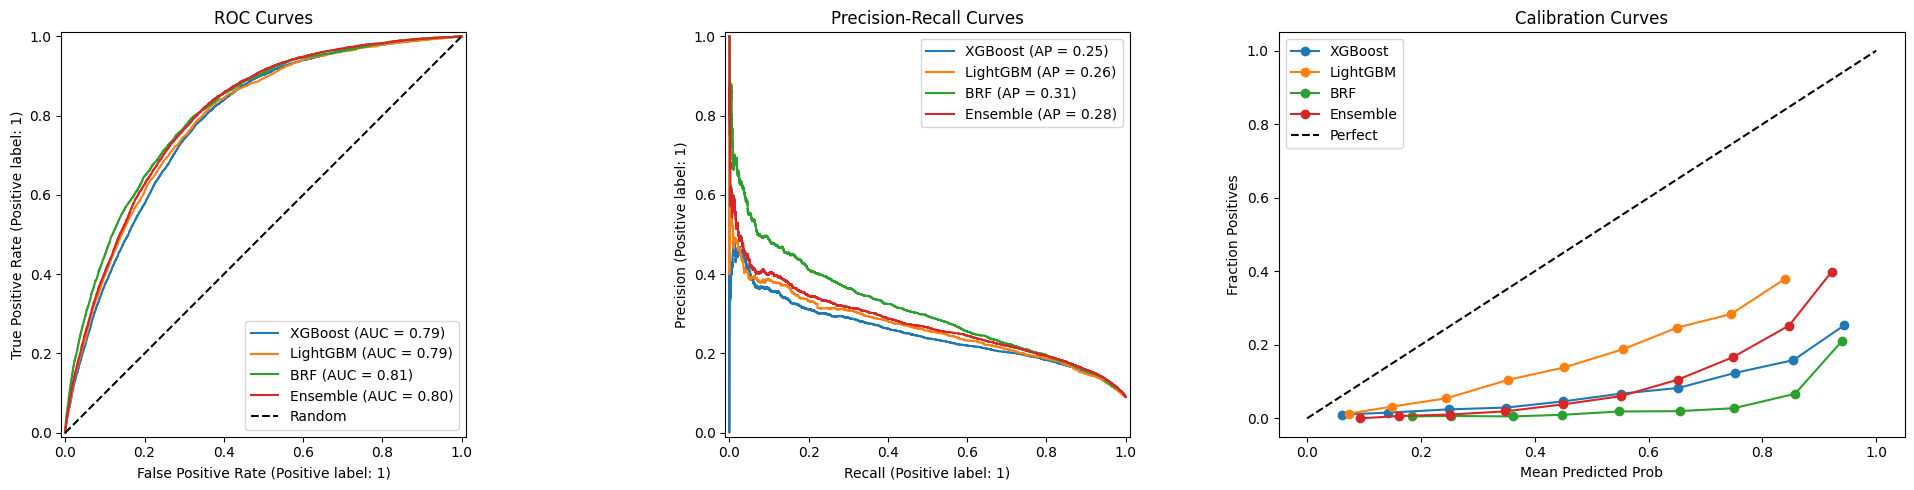

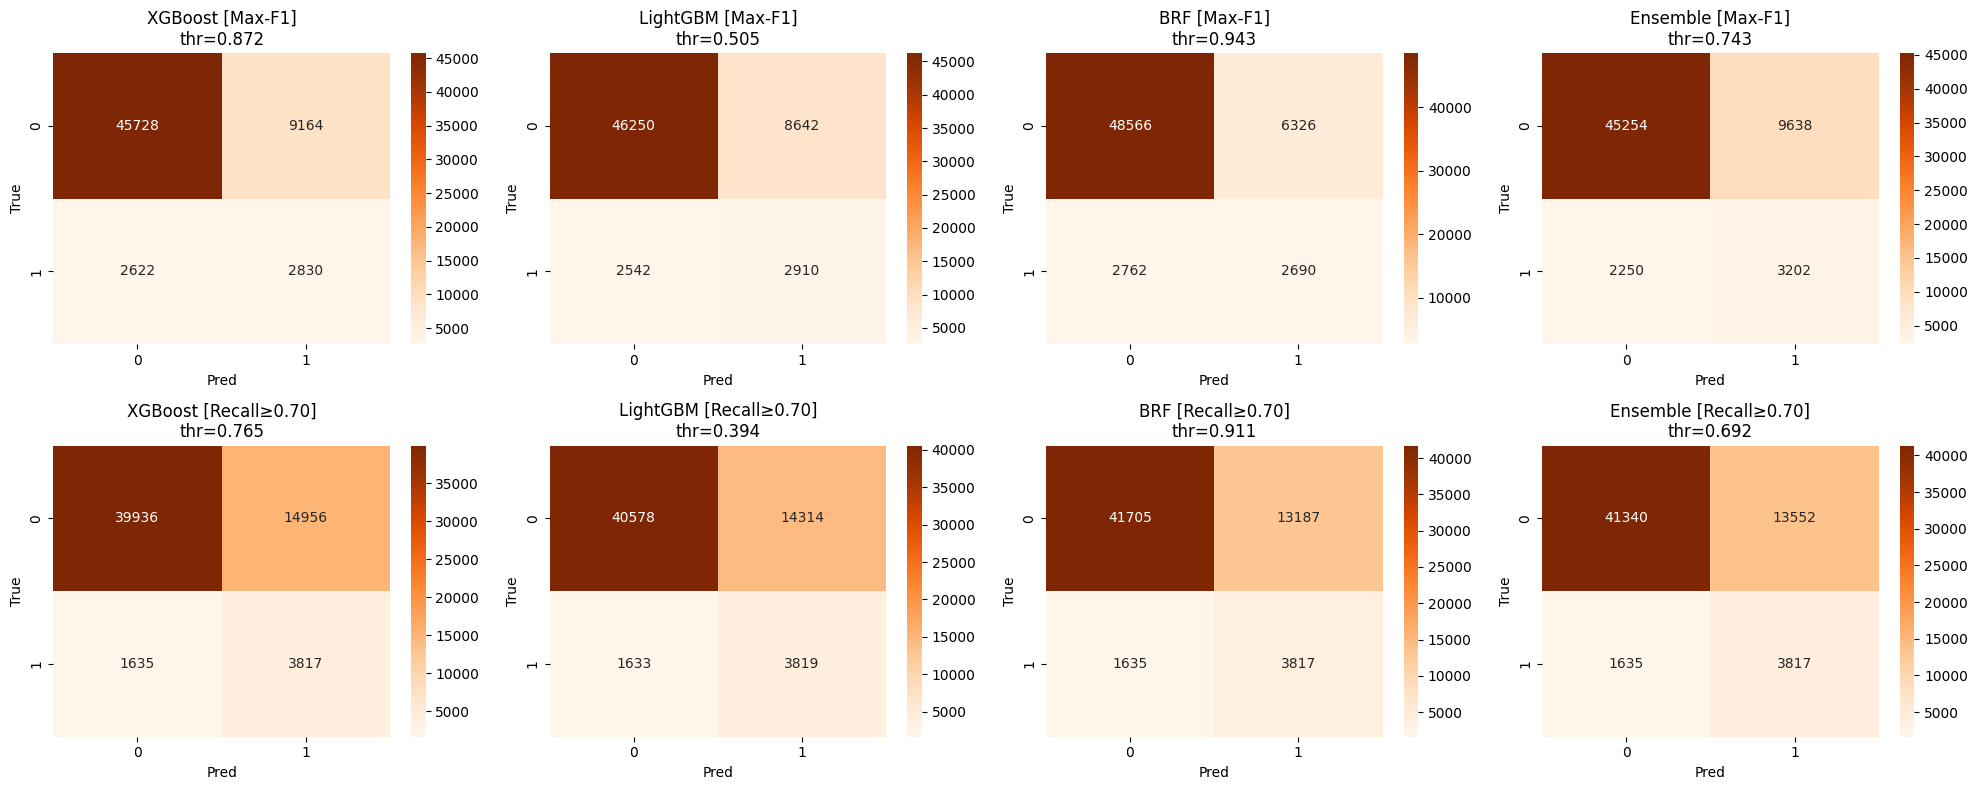

In [24]:
# ---------------------------------------------------------
# 8. Visualisations: ROC, PR, Calibration, Confusion Matrices
# ---------------------------------------------------------

model_probas = [
    ('XGBoost',   proba_xgb,  thr_xgb_f1),
    ('LightGBM',  proba_lgbm, thr_lgbm_f1),
    ('BRF',       proba_brf,  thr_brf_f1),
    ('Ensemble',  proba_ens,  thr_ens_f1),
]

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# ROC
ax = axes[0]
for name, proba, _ in model_probas:
    RocCurveDisplay.from_predictions(y_test, proba, name=name, ax=ax)
ax.plot([0,1],[0,1],'k--', label='Random')
ax.set_title("ROC Curves"); ax.legend(loc='lower right')

# PR
ax = axes[1]
for name, proba, _ in model_probas:
    PrecisionRecallDisplay.from_predictions(y_test, proba, name=name, ax=ax)
ax.set_title("Precision-Recall Curves"); ax.legend(loc='upper right')

# Calibration
ax = axes[2]
for name, proba, _ in model_probas:
    frac_pos, mean_pred = calibration_curve(y_test, proba, n_bins=10)
    ax.plot(mean_pred, frac_pos, marker='o', label=name)
ax.plot([0,1],[0,1],'k--', label='Perfect')
ax.set_xlabel("Mean Predicted Prob"); ax.set_ylabel("Fraction Positives")
ax.set_title("Calibration Curves"); ax.legend()
plt.tight_layout(); plt.show()

# Confusion matrices (2x2 grid: F1-threshold + Recall≥0.70 threshold for ensemble)
fig, axes = plt.subplots(2, 4, figsize=(20, 8))

thresholds_pairs = [
    ('XGBoost',  proba_xgb,  thr_xgb_f1,  thr_xgb_r70),
    ('LightGBM', proba_lgbm, thr_lgbm_f1, thr_lgbm_r70),
    ('BRF',      proba_brf,  thr_brf_f1,  thr_brf_r70),
    ('Ensemble', proba_ens,  thr_ens_f1,  thr_ens_r70),
]
for col, (name, proba, thr_f1, thr_r70) in enumerate(thresholds_pairs):
    for row, (thr, label) in enumerate([(thr_f1, 'Max-F1'), (thr_r70, 'Recall≥0.70')]):
        y_pred = (proba >= thr).astype(int)
        sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d',
                    cmap='Oranges', ax=axes[row][col])
        axes[row][col].set_title(f"{name} [{label}]\nthr={thr:.3f}")
        axes[row][col].set_ylabel("True"); axes[row][col].set_xlabel("Pred")
plt.tight_layout(); plt.show()


In [25]:
# ---------------------------------------------------------
# 10. Model Selection — Pick the Best & Deep-Dive
# ---------------------------------------------------------

from sklearn.metrics import matthews_corrcoef

all_models = {
    'XGBoost':   (xgb_pipe,  proba_xgb,  thr_xgb_f1,  thr_xgb_r70),
    'LightGBM':  (lgbm_pipe, proba_lgbm, thr_lgbm_f1, thr_lgbm_r70),
    'BRF':       (brf_pipe,  proba_brf,  thr_brf_f1,  thr_brf_r70),
    'Ensemble':  (None,      proba_ens,  thr_ens_f1,  thr_ens_r70),
}

print(f"\n{'Model':<12} {'ROC-AUC':>9} {'PR-AUC':>9} {'F1':>7} {'Recall':>8} {'Precision':>10} {'MCC':>8}")
print("-" * 67)

scores = {}
for name, (pipe, proba, thr_f1, thr_r70) in all_models.items():
    y_pred = (proba >= thr_f1).astype(int)
    roc    = roc_auc_score(y_test, proba)
    prauc  = average_precision_score(y_test, proba)
    f1     = f1_score(y_test, y_pred)
    recall = (y_pred[y_test == 1] == 1).mean()
    prec   = (y_test[y_pred == 1] == 1).mean() if y_pred.sum() > 0 else 0
    mcc    = matthews_corrcoef(y_test, y_pred)
    scores[name] = {'roc': roc, 'prauc': prauc, 'f1': f1,
                    'recall': recall, 'precision': prec, 'mcc': mcc,
                    'proba': proba, 'thr_f1': thr_f1, 'thr_r70': thr_r70, 'pipe': pipe}
    print(f"{name:<12} {roc:>9.4f} {prauc:>9.4f} {f1:>7.4f} {recall:>8.4f} {prec:>10.4f} {mcc:>8.4f}")

# Select winner by PR-AUC, tiebreak ROC-AUC
best_name = max(scores, key=lambda n: (scores[n]['prauc'], scores[n]['roc']))
best      = scores[best_name]
print(f"\n Best model: {best_name}  (PR-AUC = {best['prauc']:.4f}, ROC-AUC = {best['roc']:.4f})")


Model          ROC-AUC    PR-AUC      F1   Recall  Precision      MCC
-------------------------------------------------------------------
XGBoost         0.7858    0.2499  0.3244   0.5191     0.2360   0.2530
LightGBM        0.7918    0.2627  0.3423   0.5337     0.2519   0.2742
BRF             0.8087    0.3116  0.3719   0.4934     0.2984   0.3041
Ensemble        0.8024    0.2758  0.3501   0.5873     0.2494   0.2884

 Best model: BRF  (PR-AUC = 0.3116, ROC-AUC = 0.8087)



  BRF  — Full Diagnostic Report
  ROC-AUC  : 0.8087
  PR-AUC   : 0.3116
  Brier    : 0.5350
  MCC      : 0.3041

  [Max-F1        thr=0.943]
    Recall=0.493   Precision=0.298   F1=0.372
    MCC=0.3041

  [Recall≥0.70   thr=0.911]
    Recall=0.700   Precision=0.224   F1=0.340
    MCC=0.2931

  Classification Report (Max-F1 threshold):
               precision    recall  f1-score   support

   No Disease       0.95      0.88      0.91     54892
Heart Disease       0.30      0.49      0.37      5452

     accuracy                           0.85     60344
    macro avg       0.62      0.69      0.64     60344
 weighted avg       0.89      0.85      0.87     60344



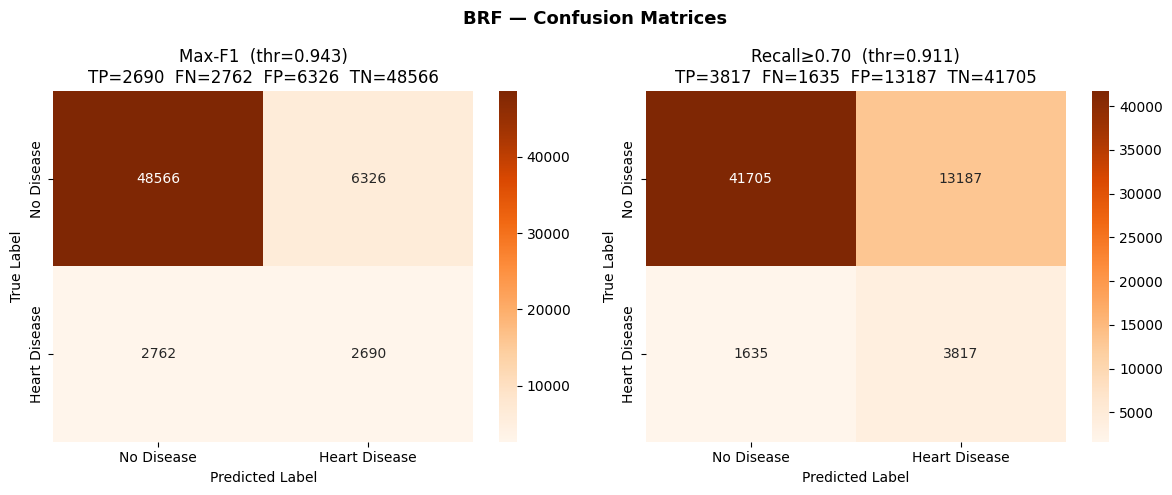

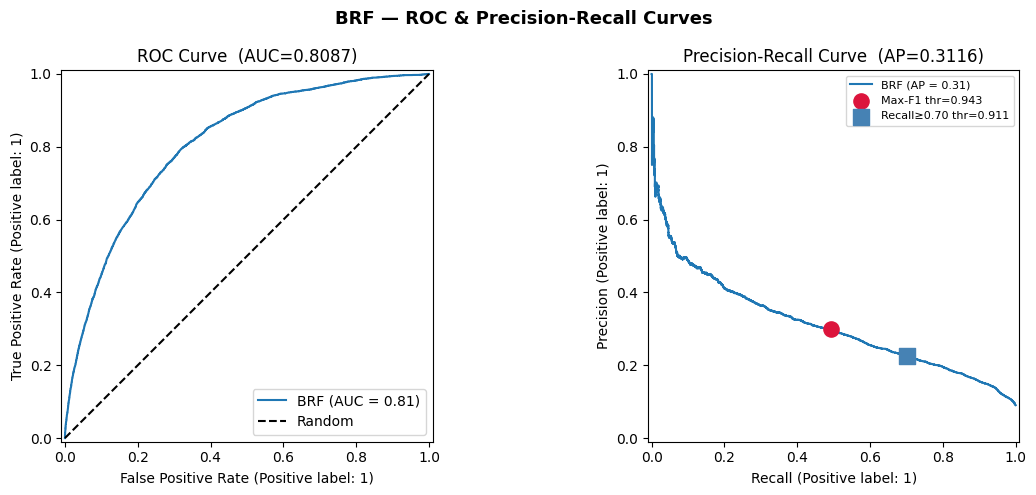

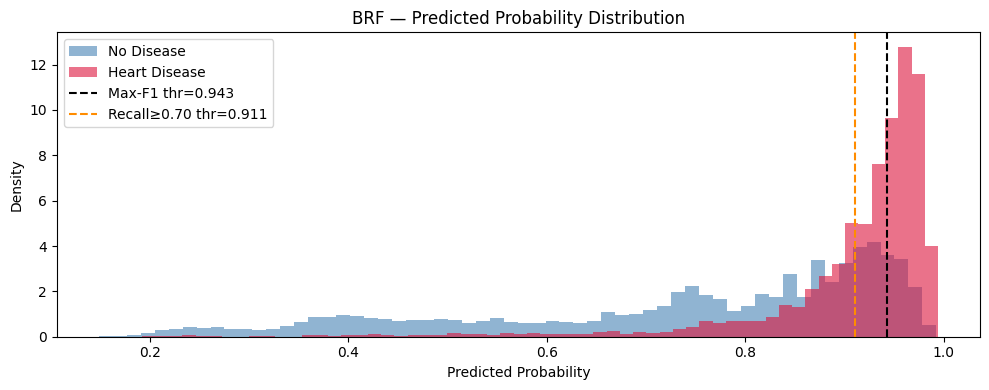

In [ ]:
# ---------------------------------------------------------
# 11. Best Model — Detailed Report
# ---------------------------------------------------------

b_proba  = best['proba']
b_thr_f1 = best['thr_f1']
b_thr_r70 = best['thr_r70']
b_pred_f1  = (b_proba >= b_thr_f1).astype(int)
b_pred_r70 = (b_proba >= b_thr_r70).astype(int)

print(f"\n{'='*60}")
print(f"  {best_name}  — Full Diagnostic Report")
print(f"{'='*60}")
print(f"  ROC-AUC  : {best['roc']:.4f}")
print(f"  PR-AUC   : {best['prauc']:.4f}")
print(f"  Brier    : {brier_score_loss(y_test, b_proba):.4f}")
print(f"  MCC      : {best['mcc']:.4f}")

for label, thr, y_pred in [
    ('Max-F1      ', b_thr_f1,  b_pred_f1),
    ('Recall≥0.70 ', b_thr_r70, b_pred_r70),
]:
    rec  = (y_pred[y_test == 1] == 1).mean()
    prec = (y_test[y_pred == 1] == 1).mean() if y_pred.sum() > 0 else 0
    print(f"\n  [{label}  thr={thr:.3f}]")
    print(f"    Recall={rec:.3f}   Precision={prec:.3f}   F1={f1_score(y_test, y_pred):.3f}")
    print(f"    MCC={matthews_corrcoef(y_test, y_pred):.4f}")

print(f"\n  Classification Report (Max-F1 threshold):")
print(classification_report(y_test, b_pred_f1, target_names=['No Disease', 'Heart Disease']))

# Calculate the third threshold and its predictions
avg_thr = (b_thr_f1 + b_thr_r70) / 2
y_pred_avg = (best_proba >= avg_thr).astype(int)

# ---- Figure 1: Confusion matrices side-by-side ----
# Changed from (1, 2) to (1, 3) and increased figsize width
fig, axes = plt.subplots(1, 3, figsize=(18, 5)) 
fig.suptitle(f"{best_name} — Confusion Matrices", fontsize=13, fontweight='bold')

# Zip now handles three sets of data
plot_data = [
    (b_thr_f1,  b_pred_f1,  f'Max-F1 (thr={b_thr_f1:.3f})'),
    (b_thr_r70, b_pred_r70, f'Recall≥0.70 (thr={b_thr_r70:.3f})'),
    (avg_thr,   y_pred_avg, f'Avg Threshold (thr={avg_thr:.3f})')
]

for ax, (thr, y_pred, label) in zip(axes, plot_data):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', ax=ax, cbar=False,
                xticklabels=['No Disease', 'Heart Disease'],
                yticklabels=['No Disease', 'Heart Disease'])
    
    tn, fp, fn, tp = cm.ravel()
    ax.set_title(f"{label}\nTP={tp}  FN={fn}  FP={fp}  TN={tn}", fontsize=11)
    ax.set_ylabel("True Label")
    ax.set_xlabel("Predicted Label")

plt.tight_layout()
plt.show()

# ---- Figure 2: ROC + PR for best model ----
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle(f"{best_name} — ROC & Precision-Recall Curves", fontsize=13, fontweight='bold')

RocCurveDisplay.from_predictions(y_test, b_proba, name=best_name, ax=axes[0])
axes[0].plot([0,1],[0,1],'k--', label='Random'); axes[0].legend()
axes[0].set_title(f"ROC Curve  (AUC={best['roc']:.4f})")

PrecisionRecallDisplay.from_predictions(y_test, b_proba, name=best_name, ax=axes[1])
axes[1].set_title(f"Precision-Recall Curve  (AP={best['prauc']:.4f})")

# Mark operating thresholds on PR curve
for thr, marker, color, lbl in [
    (b_thr_f1,  'o', 'crimson',   f'Max-F1 thr={b_thr_f1:.3f}'),
    (b_thr_r70, 's', 'steelblue', f'Recall≥0.70 thr={b_thr_r70:.3f}'),
]:
    y_pred  = (b_proba >= thr).astype(int)
    rec_pt  = (y_pred[y_test == 1] == 1).mean()
    prec_pt = (y_test[y_pred == 1] == 1).mean() if y_pred.sum() > 0 else 0
    axes[1].scatter(rec_pt, prec_pt, marker=marker, color=color, s=120, zorder=5, label=lbl)
axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

# ---- Figure 3: Probability distribution ----
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(b_proba[y_test == 0], bins=60, alpha=0.6, label='No Disease', color='steelblue', density=True)
ax.hist(b_proba[y_test == 1], bins=60, alpha=0.6, label='Heart Disease', color='crimson', density=True)
ax.axvline(b_thr_f1,  color='black',   linestyle='--', label=f'Max-F1 thr={b_thr_f1:.3f}')
ax.axvline(b_thr_r70, color='darkorange', linestyle='--', label=f'Recall≥0.70 thr={b_thr_r70:.3f}')
ax.set_xlabel("Predicted Probability"); ax.set_ylabel("Density")
ax.set_title(f"{best_name} — Predicted Probability Distribution")
ax.legend(); plt.tight_layout(); plt.show()


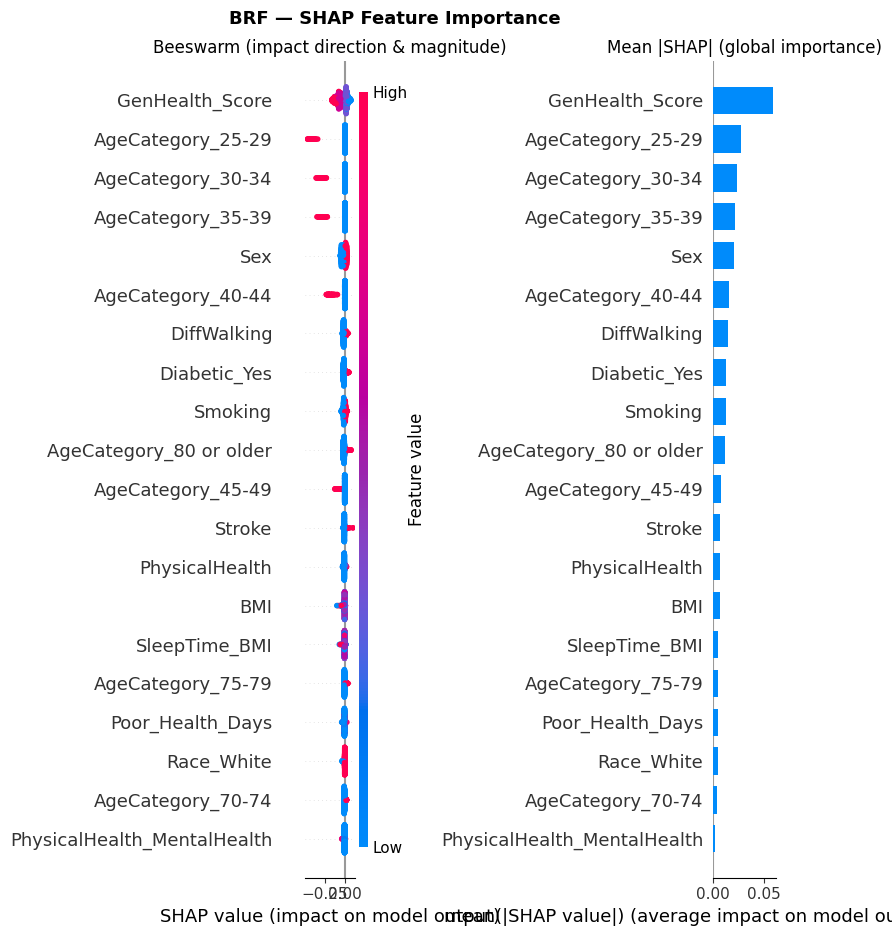


-> Top feature by mean |SHAP|: GenHealth_Score


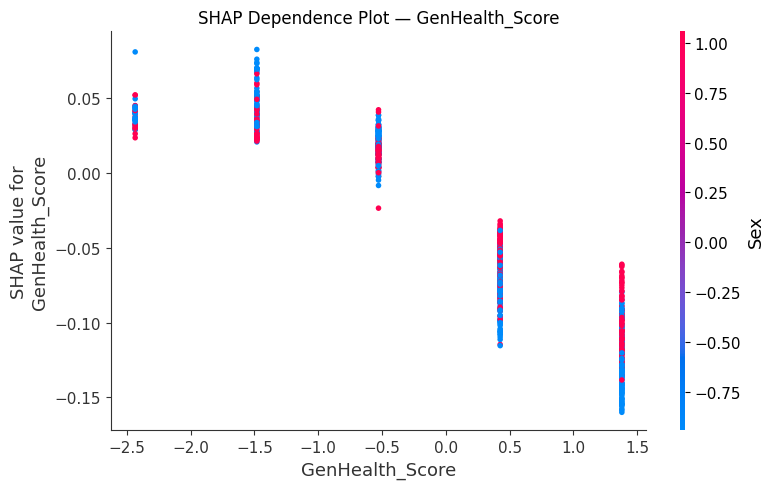

In [27]:
# ---------------------------------------------------------
# 12. Best Model — SHAP Explainability
# ---------------------------------------------------------
import shap

# Works for any tree-based single pipeline; Ensemble falls back to XGBoost
shap_pipe = best['pipe'] if best['pipe'] is not None else xgb_pipe
shap_name = best_name    if best['pipe'] is not None else "XGBoost (Ensemble fallback)"

selector_step = shap_pipe.named_steps['select']
scaler_step   = shap_pipe.named_steps['scaler']
model_step    = shap_pipe.named_steps['model']

X_test_scaled   = scaler_step.transform(X_test_raw)
X_test_selected = selector_step.transform(X_test_scaled)
sel_features    = X_test_raw.columns[selector_step.get_support()].tolist()
X_shap_df       = pd.DataFrame(X_test_selected, columns=sel_features)
X_shap_sample   = X_shap_df.sample(n=1000, random_state=42)

explainer   = shap.TreeExplainer(model_step)
shap_values = explainer.shap_values(X_shap_sample)

# Normalise to 2D (samples x features) for all model types
sv = shap_values
if isinstance(sv, list):
    sv = sv[1]
if hasattr(sv, 'ndim') and sv.ndim == 3:
    sv = sv[:, :, 1]

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle(f"{shap_name} — SHAP Feature Importance", fontsize=13, fontweight='bold')

plt.sca(axes[0])
shap.summary_plot(sv, X_shap_sample, show=False)
axes[0].set_title("Beeswarm (impact direction & magnitude)")

plt.sca(axes[1])
shap.summary_plot(sv, X_shap_sample, plot_type='bar', show=False)
axes[1].set_title("Mean |SHAP| (global importance)")

plt.tight_layout(); plt.show()

# ---- SHAP dependence plot for top feature ----
# Normalise shap_values to 2D (samples x features) regardless of model type
sv = shap_values
if sv.ndim == 3:          # e.g. BalancedRF returns (samples, features, classes)
    sv = sv[:, :, 1]      # take positive class
elif isinstance(sv, list):
    sv = sv[1]            # older SHAP list format

top_feature = X_shap_sample.columns[np.abs(sv).mean(axis=0).argmax()]
print(f"\n-> Top feature by mean |SHAP|: {top_feature}")
fig, ax = plt.subplots(figsize=(8, 5))
shap.dependence_plot(top_feature, sv, X_shap_sample, ax=ax, show=False)
ax.set_title(f"SHAP Dependence Plot — {top_feature}")
plt.tight_layout(); plt.show()


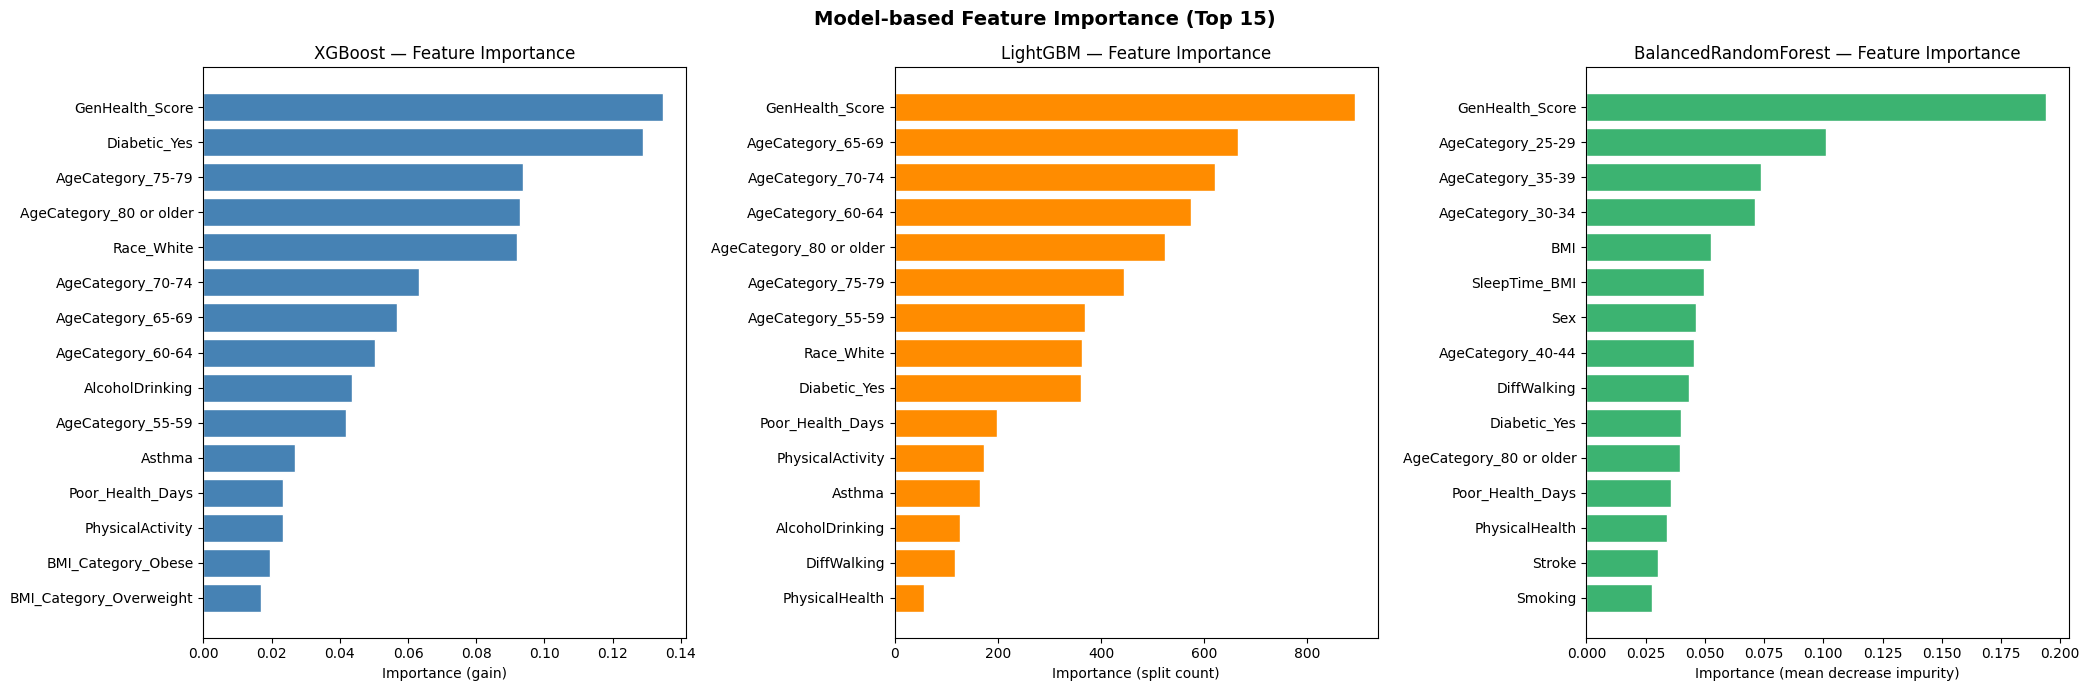


-> Features in top 15 for all models (4):
   • AgeCategory_80 or older
   • Diabetic_Yes
   • GenHealth_Score
   • Poor_Health_Days


In [28]:
# ---------------------------------------------------------
# 13. Feature Importance — Model Bazlı (Built-in) Karşılaştırması
# ---------------------------------------------------------

fig, axes = plt.subplots(1, 3, figsize=(21, 7))
fig.suptitle("Model-based Feature Importance (Top 15)", fontsize=14, fontweight='bold')

# ---- XGBoost ----
xgb_model_inner = xgb_pipe.named_steps['model']
xgb_selector    = xgb_pipe.named_steps['select']
xgb_feat_names  = X_test_raw.columns[xgb_selector.get_support()].tolist()
xgb_fi = pd.Series(xgb_model_inner.feature_importances_, index=xgb_feat_names).nlargest(15)
axes[0].barh(xgb_fi.index[::-1], xgb_fi.values[::-1], color='steelblue', edgecolor='white')
axes[0].set_title("XGBoost — Feature Importance")
axes[0].set_xlabel("Importance (gain)")

# ---- LightGBM ----
lgbm_model_inner = lgbm_pipe.named_steps['model']
lgbm_selector    = lgbm_pipe.named_steps['select']
lgbm_feat_names  = X_test_raw.columns[lgbm_selector.get_support()].tolist()
lgbm_fi = pd.Series(lgbm_model_inner.feature_importances_, index=lgbm_feat_names).nlargest(15)
axes[1].barh(lgbm_fi.index[::-1], lgbm_fi.values[::-1], color='darkorange', edgecolor='white')
axes[1].set_title("LightGBM — Feature Importance")
axes[1].set_xlabel("Importance (split count)")

# ---- BalancedRandomForest ----
brf_model_inner = brf_pipe.named_steps['model']
brf_selector    = brf_pipe.named_steps['select']
brf_feat_names  = X_test_raw.columns[brf_selector.get_support()].tolist()
brf_fi = pd.Series(brf_model_inner.feature_importances_, index=brf_feat_names).nlargest(15)
axes[2].barh(brf_fi.index[::-1], brf_fi.values[::-1], color='mediumseagreen', edgecolor='white')
axes[2].set_title("BalancedRandomForest — Feature Importance")
axes[2].set_xlabel("Importance (mean decrease impurity)")

plt.tight_layout(); plt.show()

common = set(xgb_fi.index) & set(lgbm_fi.index) & set(brf_fi.index)
print(f"\n-> Features in top 15 for all models ({len(common)}):")
for feat in sorted(common):
    print(f"   • {feat}")
